In [1]:
import sys
import os
sys.path.append("/home/karlandersson/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/MasterThesisProject/scripts/vapour_reactor


In [2]:
import json
import matplotlib.pyplot as plt

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config_seq
from utils.vapour_reactor_utils import plot_reactor_solutions

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

In [3]:
with open("../../data/reactor_data.json", "r") as f:
    data = json.load(f)

In [4]:
Ns = [[45, 65, 40], [45, 65, 40]]
cfgs = generate_config_seq(data, Ns)

reactors = [Reactor(cfgs[0]), VapourReactor(cfgs[1])]

Mesh warning: N_Z changed from 40 to 39
Mesh warning: Fuel pin N_Z changed from 18 to 27
Mesh warning: Neutronics N_Z changed from 18 to 27
Mesh warning: N_Z changed from 40 to 39
Mesh warning: Fuel pin N_Z changed from 18 to 27
Mesh warning: Neutronics N_Z changed from 18 to 27


In [5]:
solver = Solver(reactors, iterate=True)
solver.fsolve()

Running iteration 1 ...


Running iteration 2 ...


/home/karlandersson/MasterThesisProject/utils/sodium_properties.py:69: RuntimeWarning: invalid value encountered in power
  return 1e3 * (393.37 * (1 - T_vapour / T_crit_Na) + 4398.6 * (1 - T_vapour / T_crit_Na)**(0.29302))
/home/karlandersson/MasterThesisProject/utils/solver.py:61: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return solver_fn(component.get_residuals, x_initial, **valid_kwargs)


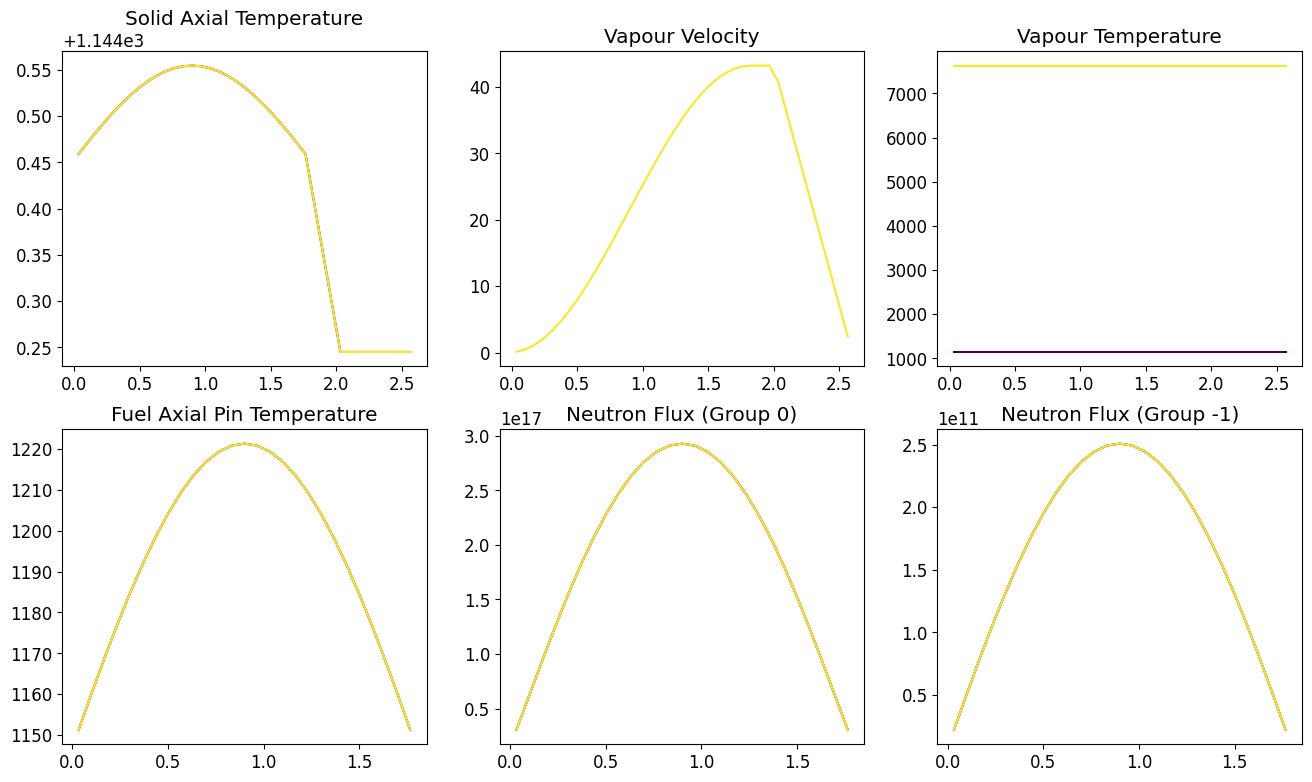

In [6]:
plot_reactor_solutions(solver)